In [1]:
import os
import sys
# Get the absolute path of the current notebook's directory
notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
sys.path.append(parent_dir)  # Add parent directory to sys.path

# model
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as tg
import torch_scatter
from typing import Dict, Union

# crystal structure data
palette = ['#43AA8B', '#F8961E', '#F94144']
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
# data pre-processing and visualization
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pandas as pd
from scipy.interpolate import interp1d
import math
import e3nn.o3 as o3
from e3nn.util.jit import compile_mode
from e3nn.io import CartesianTensor

# utilities
import time
from mendeleev import element
from tqdm import tqdm
from utils.utils_data import load_data, train_valid_test_split, save_or_load_onehot, build_data, format_chemical_formula
from utils.utils_model_full_tensor import Network, train, evaluate
import wandb
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.ticker import MaxNLocator

bar_format = '{l_bar}{bar:10}{r_bar}{bar:-10b}'
default_dtype = torch.float64
torch.set_default_dtype(default_dtype)

# Create a colormap based on the number of unique symbols
datasets = ['g', 'y', 'r']
colors = dict(zip(datasets, palette))
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap', [palette[k] for k in [0,2,1]])


# Check device
device = "cuda:3" if torch.cuda.is_available() else "cpu"
print('torch device:' , device)


## load data
data_file = '../dataset/symmetrized_dataset_with_bandgap.pkl'
df, species = load_data(data_file)
df = df.reset_index(drop=True)

print('data acquired')

energy_min = 0 #Unit of energy in eV
energy_max = 30 #Unit of energy in eV
nstep = 300 #Number of the energy points

new_x = np.linspace(energy_min, energy_max, nstep)
# Efficiently interpolate all matrices using list comprehension
def interpolate_matrix(matrix, omega):
    """Interpolates the full (3001, 3, 3) matrix along the energy axis."""
    interp = interp1d(omega, matrix, kind='linear', axis=0, fill_value=0, bounds_error=False)
    return interp(new_x) 


# Apply interpolation efficiently
df['rel_permittivity_imag_interp'] = [
    interpolate_matrix(row['rel_permittivity_imag'], row['omega']) for _, row in df.iterrows()
]
# Apply the custom function to create a new column
df['energies_interp'] = df.apply(lambda x: new_x, axis=1)


stack_matrices_tensor = torch.tensor(np.stack(df['rel_permittivity_imag_interp'].values), dtype=default_dtype, device=device)
x = CartesianTensor("ij=ji")
sph_coefs_tensor = x.from_cartesian(stack_matrices_tensor)
scalar_0e = sph_coefs_tensor[:, :, 0]     # (N, F)
tensor_2e = sph_coefs_tensor[:, :, 1:]    # (N, F, 5)

scale_0e = torch.mean(torch.max(torch.abs(scalar_0e), dim=1).values)
scale_2e = torch.median(torch.max(torch.norm(tensor_2e, dim=-1), dim=1).values) 
# === Normalize ===
scalar_0e /= (scale_0e + 1e-12)
tensor_2e /= (scale_2e.unsqueeze(-1) + 1e-12)
print(scale_0e, scale_2e)
# Merge back
sph_coefs_tensor = torch.cat([scalar_0e.unsqueeze(-1), tensor_2e], dim=-1)  # (N, F, 6)

df['sph_coefs'] = list(sph_coefs_tensor.cpu().numpy())

type_onehot, mass_onehot, dipole_onehot, radius_onehot, type_encoding = save_or_load_onehot()
scale_data = 1

r_max = 6. # cutoff radius
df['data'] = df.progress_apply(lambda x: build_data(x, 'sph_coefs', scale_data, type_onehot, mass_onehot, dipole_onehot, radius_onehot, type_encoding, r_max), axis=1)


torch device: cuda:3
data acquired
tensor(12.0045, device='cuda:3') tensor(2.4356, device='cuda:3')
Loading existing data...


100%|██████████| 1432/1432 [00:22<00:00, 63.21it/s]


In [2]:
run_time = '250909'
with open('../model/idx_train_'+run_time+'.txt', 'r') as f: idx_train = [int(i.split('\n')[0]) for i in f.readlines()]
with open('../model/idx_valid_'+run_time+'.txt', 'r') as f: idx_valid = [int(i.split('\n')[0]) for i in f.readlines()]
with open('../model/idx_test_'+run_time+'.txt', 'r') as f: idx_test = [int(i.split('\n')[0]) for i in f.readlines()]

def get_neighbors(df, idx):                                                    
    n = []
    for entry in df.iloc[idx].itertuples():
        N = entry.data.pos.shape[0]
        for i in range(N):
            n.append(len((entry.data.edge_index[0] == i).nonzero()))
    return np.array(n)

n_train = get_neighbors(df, idx_train)
print(n_train.mean())
n_valid = get_neighbors(df, idx_valid)
n_test = get_neighbors(df, idx_test)
INPUT_FEATURE_DIM = 118
EMBEDDING_DIM = 64

from utils.eatgnn_ori import Network, train

number_of_basis = 10  # Number of basis functions for the radial basis function expansion
lmax = 2
trial_params = {'irreps_0e': 32,
                'irreps_1e': 16,
                'irreps_2e': 8,
                'irreps_3e': 4}
irreps_query = f"{trial_params['irreps_0e']}x0e+{trial_params['irreps_1e']}x1e+{trial_params['irreps_2e']}x2e+{trial_params['irreps_3e']}x3e"
# irreps_out = f"{trial_params['irreps_0e'] * 2}x0e+{trial_params['irreps_1e'] * 2}x1e+{trial_params['irreps_2e'] * 2}x2e + {trial_params['irreps_3e'] * 2}x3e"
irreps_out = f"300x0e+300x2e"
model = Network(
    irreps_in="{}x0e".format(EMBEDDING_DIM),
    embedding_dim=EMBEDDING_DIM,
    irreps_query=irreps_query,
    irreps_key=irreps_query,
    irreps_out = irreps_out,
    formula="ij=ji",
    lmax=lmax, 
    max_radius=r_max,
    number_of_basis = number_of_basis,
    num_nodes=n_train.mean(),
    pool_nodes=True,
)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

class NetWrapper(nn.Module):
    def __init__(self, in_dim, em_dim, gat_model):
        super().__init__()
        self.gat_model = gat_model
        self.em_z = nn.Linear(in_dim, em_dim)
        self.em_x = nn.Linear(in_dim, em_dim)

    def forward(self, data):
        data.z = F.relu(self.em_z(data.z))
        data.x = F.relu(self.em_x(data.x))
        return self.gat_model(data)

model = NetWrapper(INPUT_FEATURE_DIM, EMBEDDING_DIM, model)

# run_name = f'eatgnn_optuna_trial_0'
run_name = f'TSENN-A_{run_time}_Lmax_{lmax}'
wandb.init(
    project="Prediction",  # Change this to your project name
    name=run_name,  # Unique identifier for this run
    config={
    }
)

# predict on all data
model.load_state_dict(torch.load('../model/'+run_name + '_best.torch', map_location=device)['state'])

model.pool = True

dataloader = tg.loader.DataLoader(df['data'].values, batch_size=64)
df['mse_sph'] = 0.
df['y_pred_sph'] = np.empty((len(df), 0)).tolist()

model.to(device)
model.eval()

predictions = [] 
df['y_pred_sph'] = None
i0 = 0
with torch.no_grad():
    for i, d in tqdm(enumerate(dataloader), total=len(dataloader), bar_format=bar_format):
        d.to(device)
        output = model(d)
        irreps_0e = 300
        irreps_2e = 1500
        out_dim = 300
        # irreps_0e = model.irreps_out.count(o3.Irrep("0e"))
        # irreps_2e = model.irreps_out.count(o3.Irrep("2e")) * 5
        # out_dim = model.irreps_out.count(o3.Irrep("0e")) 
        
        output_0e = output[:, :irreps_0e] * scale_0e # Shape: (batch_size, irreps_0e)
        output_2e = output[:, irreps_0e:irreps_0e + irreps_2e].contiguous().view(output.shape[0], out_dim, 5) * scale_2e # Shape: (batch_size, 201, 5)

        y_0e = d.y[:, :, 0].view(d.y.shape[0], out_dim) *scale_0e
        y_2e = d.y[:, :, 1:].view(d.y.shape[0], out_dim, 5) * scale_2e # Shape: (batch_size, 201, 5)

        loss_0e = F.l1_loss(output_0e, y_0e)   # MAE or other suitable loss
        loss_2e = F.l1_loss(output_2e, y_2e)   # MAE or other suitable loss
        loss = loss_0e + loss_2e
        
        combined_output = torch.cat([output_0e.unsqueeze(2), output_2e], dim=2)  # Shape: (batch_size, 201, 6)
        predictions.append(combined_output.cpu())

        for batch_idx in range(d.y.shape[0]):
            df.loc[i0 + batch_idx, 'y_pred_sph'] = [combined_output[batch_idx].cpu().numpy()]
            df.loc[i0 + batch_idx, 'mse_sph'] = loss.cpu().numpy() * scale_data

        # Update batch index counter
        i0 += d.y.shape[0]

column = 'rel_permittivity_imag_interp'

df['y_pred_sph'] = df['y_pred_sph'].map(lambda x: x[0]) * scale_data


# Convert all spherical tensors to a batched tensor
sph_tensors = torch.tensor(np.stack(df['y_pred_sph'].values))  # Batch process

# Convert using x.to_cartesian in batch
cart_tensors = x.to_cartesian(sph_tensors)

# Assign back to the DataFrame
df['y_pred_cart'] = list(cart_tensors.numpy())  # Convert back to list of NumPy arrays

# Convert to NumPy arrays
cart_true = np.stack(df[column].values)  # Shape: (num_samples, 301, 3, 3)
cart_pred = np.stack(df['y_pred_cart'].values)  # Shape: (num_samples, 301, 3, 3)

# Convert to PyTorch tensors
cart_true_tensor = torch.tensor(cart_true, dtype=torch.float64)
cart_pred_tensor = torch.tensor(cart_pred, dtype=torch.float64)

# Get upper diagonal indices of symmetric 3x3 tensor
inds_diag = [(0, 0), (1, 1), (2, 2)]
inds_off = [(0, 1), (0, 2), (1, 2)]

# Gather errors for each of the 6 unique components
def mae_symmetric_only(pred, true):
    errors = []
    for i, j in inds_diag + inds_off:
        errors.append(torch.abs(pred[:, :, i, j] - true[:, :, i, j]))  # shape: (N, freq)
    errors = torch.stack(errors, dim=0)  # shape: (6, N, freq)
    return torch.mean(errors, dim=0)  # shape: (N, freq)

# Compute MAE per sample across all frequency points
mae_cart_tensor = mae_symmetric_only(cart_pred_tensor, cart_true_tensor)  # shape: (N, freq)
mae_cart = torch.mean(mae_cart_tensor, dim=1).cpu().numpy()  # mean over frequencies
df['mae_cart'] = mae_cart

sph_true = torch.tensor(np.stack(df['sph_coefs'].values))  
sph_pred = torch.tensor(np.stack(df['y_pred_sph'].values))
mae_sph = torch.mean(torch.abs(sph_pred - sph_true), dim=(1, 2)).cpu().numpy()  
df['mae_sph'] = mae_sph


mae_sph_mean = df['mae_sph'].mean()
mae_sph_std = df['mae_sph'].std()
mae_cart_mean = df['mae_cart'].mean()
mae_cart_std = df['mae_cart'].std()
wandb.finish()


43.404443289593345


wandb: Currently logged in as: hsu-ting (hsu-ting-northeastern-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Total trainable parameters: 31775020


100%|██████████| 23/23 [00:22<00:00,  1.02it/s]


# Direct mean on $\omega$

In [3]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams["mathtext.fontset"] = "cm"
fontsize = 16
textsize = 16
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['font.size'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['xtick.labelsize'] = fontsize 
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['legend.fontsize'] = textsize
plt.rcParams['text.usetex'] = False
plt.rcParams['figure.dpi'] = 150       
plt.rcParams['savefig.dpi'] = 300      


splits = {
    "Train": idx_train,
    "Validation": idx_valid,
    "Test": idx_test
}


df['split'] = np.nan
for split_name, idx in splits.items():
    df.loc[idx, 'split'] = split_name


# sampled

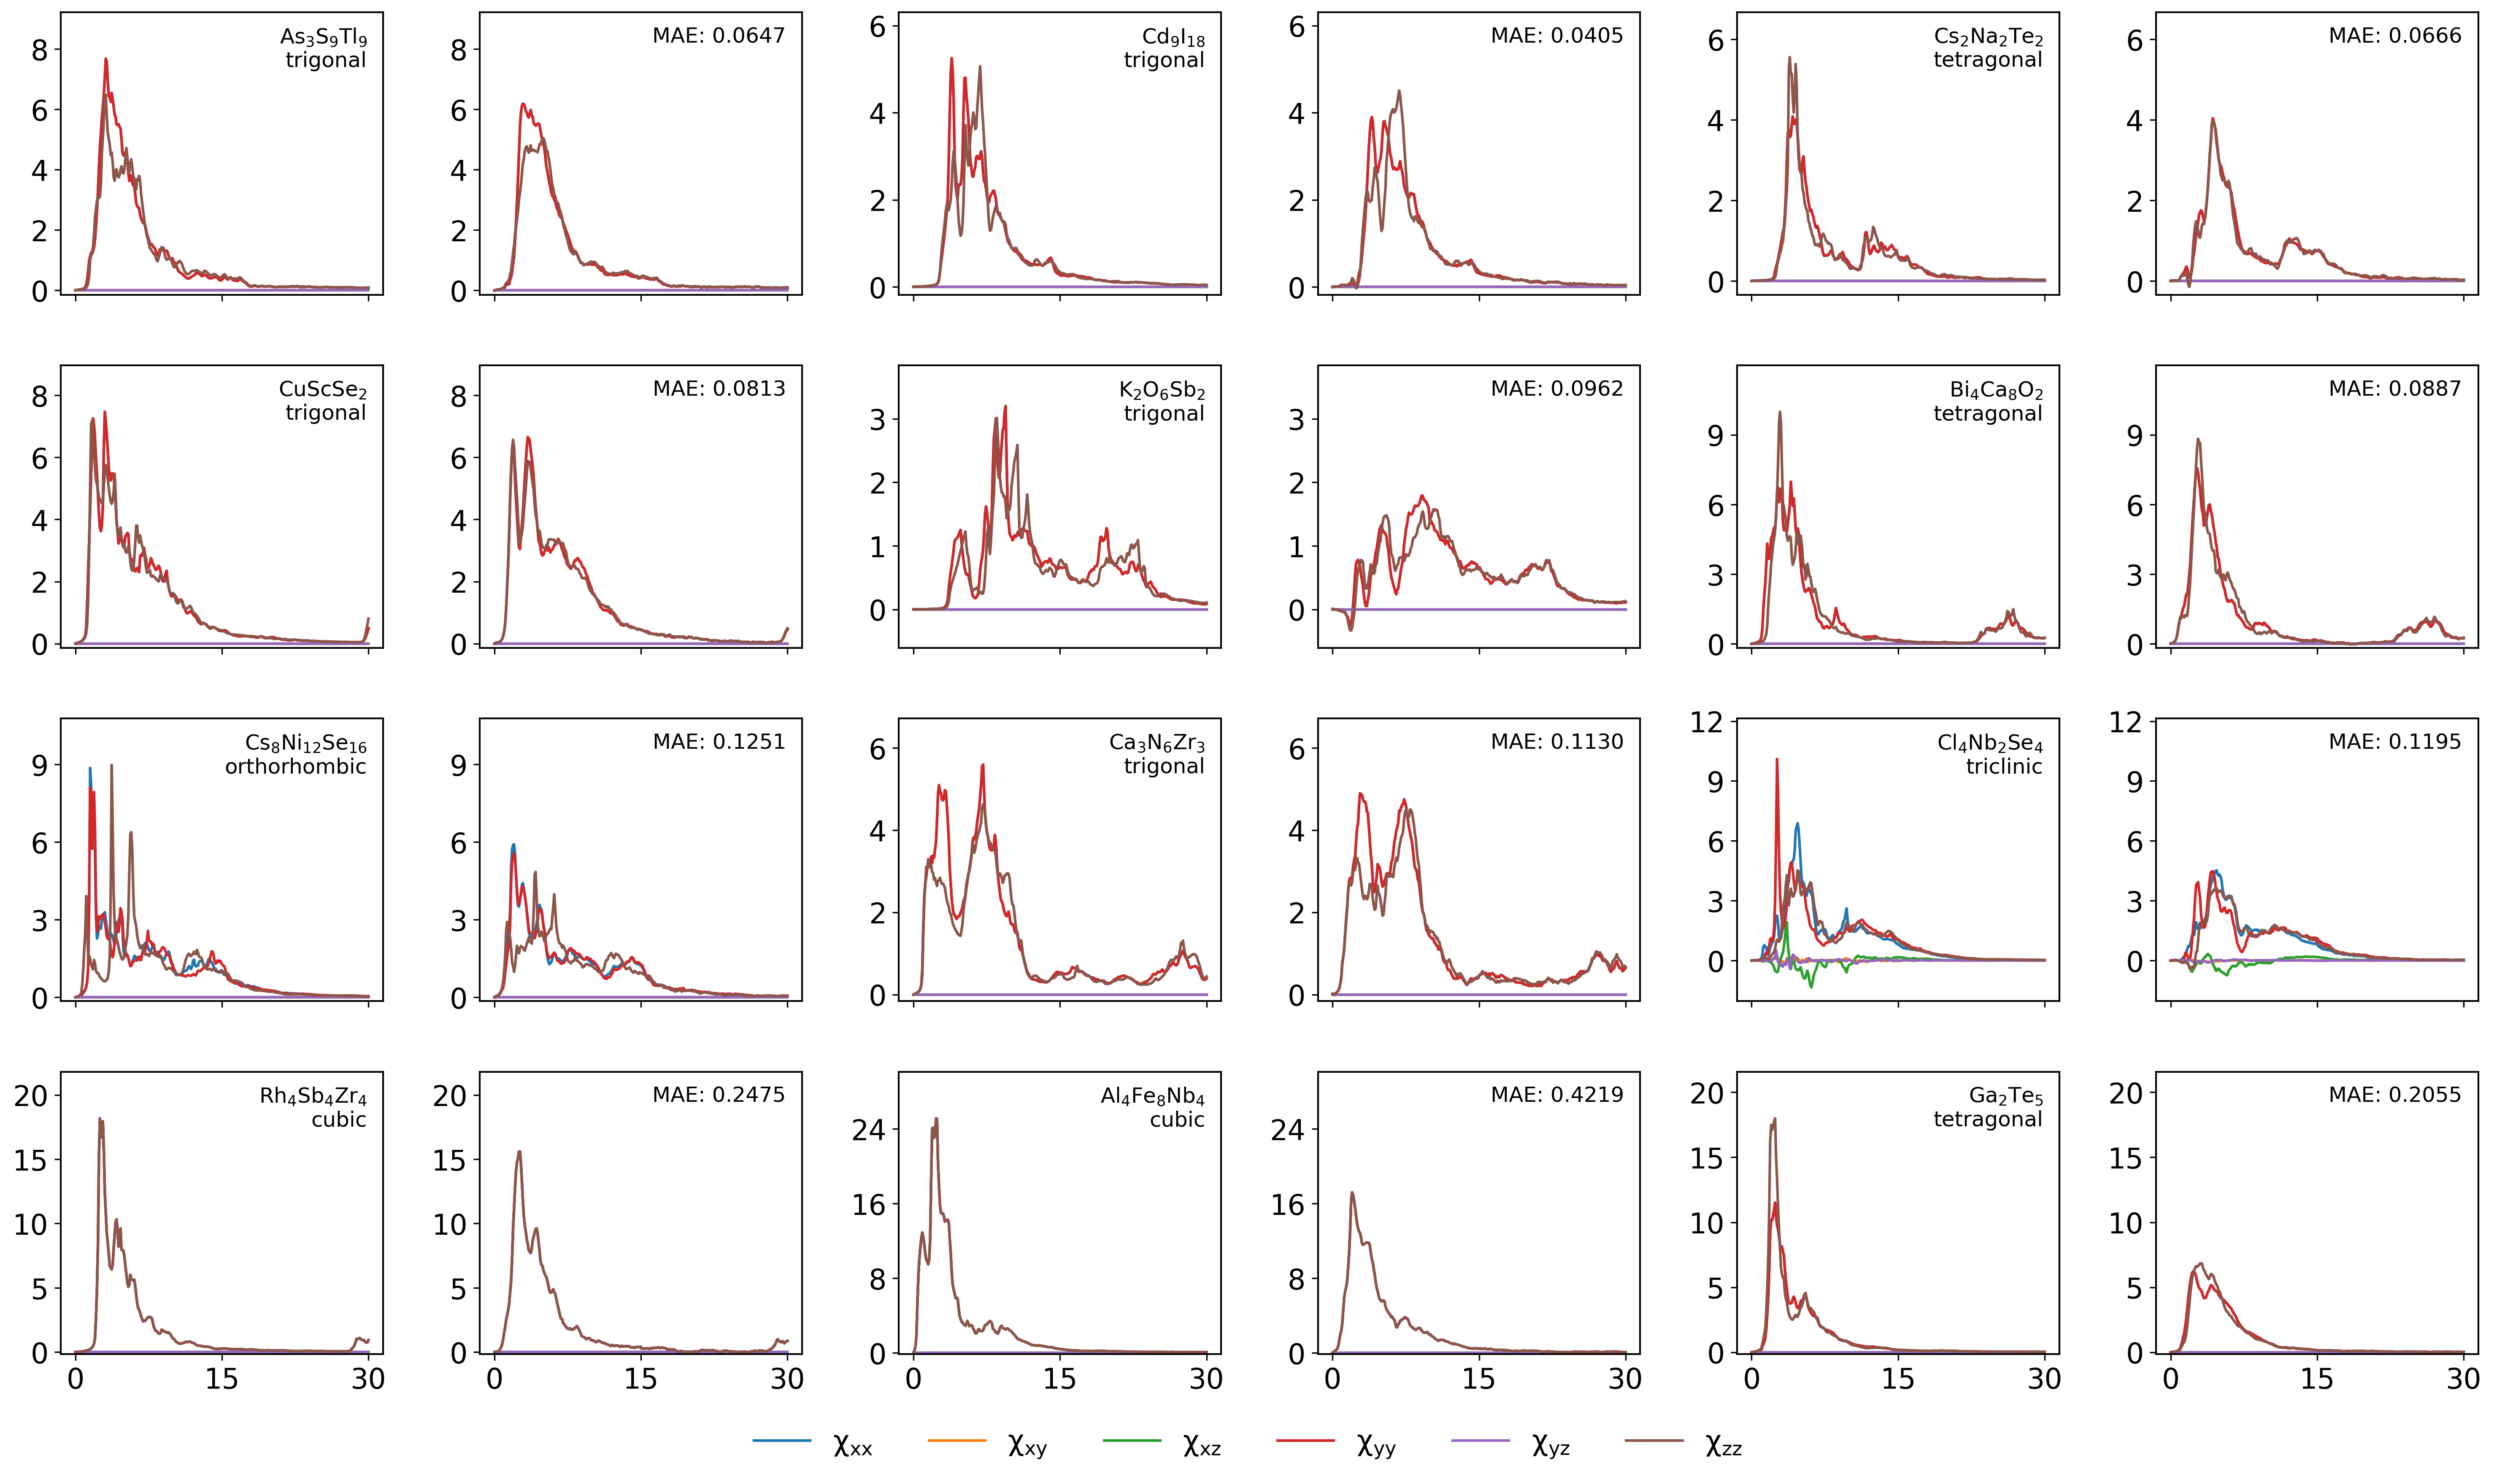

In [4]:
n_samples = 12
def sample_by_mae_quartiles(df, idx_test, n_per_quartile=3):
    """
    Robust quartile sampling from test set by `mae_cart` values.

    Returns:
        List of lists: Each sublist contains indices from one quartile.
    """
    df_test = df.loc[idx_test].copy()
    df_test = df_test.reset_index()

    # Try to divide into 4 bins (quartiles)
    try:
        df_test["mae_quartile"] = pd.qcut(
            df_test["mae_cart"].rank(method="first"), 
            q=4, 
            labels=False,
            duplicates="drop"
        )
    except ValueError as e:
        print("Warning:", e)
        return []

    grouped_indices = []
    for q in range(4):
        q_bin = df_test[df_test["mae_quartile"] == q]
        if len(q_bin) == 0:
            print(f"Skipping quartile {q} due to lack of data.")
            continue
        sampled = q_bin.sample(min(n_per_quartile, len(q_bin)), random_state=42)
        grouped_indices.append(sampled["index"].tolist())

    return grouped_indices

def plot_cartesian_tensor_comparison_by_quartile(df, grouped_idx, column_name, title_prefix=""):
    """
    Plots 3 samples per quartile in 4 rows (1 row per quartile), 6 subplots per row.

    Parameters:
    - grouped_idx: List of 4 sublists (each from a quartile)
    """
    xyz_list = ['x', 'y', 'z']
    tensor_components = [f"$\chi_{{{xyz_list[a]}{xyz_list[b]}}}$" for a in range(3) for b in range(a, 3)]
    total_samples = sum(len(g) for g in grouped_idx)

    fig, axes = plt.subplots(4, 6, figsize=(20, 12), dpi=300, sharex=True)
    axes = axes.reshape(4, 6)

    handles, labels = [], []
    sample_idx = 0

    for row_idx, quartile_group in enumerate(grouped_idx):
        for col_idx, idx_val in enumerate(quartile_group):
            ds_row = df.loc[idx_val]
            omega = ds_row["energies_interp"]
            real = ds_row[column_name]
            pred = ds_row["y_pred_cart"]
            formula = format_chemical_formula(ds_row["formula"])
            system = ds_row["crystal_system"]
            mae = ds_row["mae_cart"]

            y_min = min(real.min(), pred.min())
            y_max = max(real.max(), pred.max())

            ax_real = axes[row_idx, col_idx * 2]
            ax_pred = axes[row_idx, col_idx * 2 + 1]

            for i, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
                h, = ax_real.plot(omega, real[:, a, b], label=tensor_components[i])
                ax_pred.plot(omega, pred[:, a, b])
                if sample_idx == 0:
                    handles.append(h)
                    labels.append(tensor_components[i])

            for ax in (ax_real, ax_pred):
                ax.set_ylim((y_min - 0.1) * 1.4, y_max * 1.2)
                ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
                ax.set_xticks([])

            ax_real.text(0.95, 0.95, f"${formula}$\n{system}",
                         transform=ax_real.transAxes, fontsize=12, va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            ax_pred.text(0.95, 0.95, f"MAE: {mae:.4f}",
                         transform=ax_pred.transAxes, fontsize=12, va='top', ha='right',
                         bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

            sample_idx += 1

    for ax in axes[-1, :]:
        ax.set_xticks(np.linspace(min(omega), max(omega), 3))

    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=6, fontsize=16, frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.subplots_adjust(wspace=0.3, hspace=0.25)

    os.makedirs("../pngs", exist_ok=True)
    fig.savefig(f"../pngs/{title_prefix}_quartile_grid.png", dpi=300)
    plt.show()
grouped_idx = sample_by_mae_quartiles(df, idx_test, n_per_quartile=3)
plot_cartesian_tensor_comparison_by_quartile(df, grouped_idx, column_name=column, title_prefix="mae_quartiles")

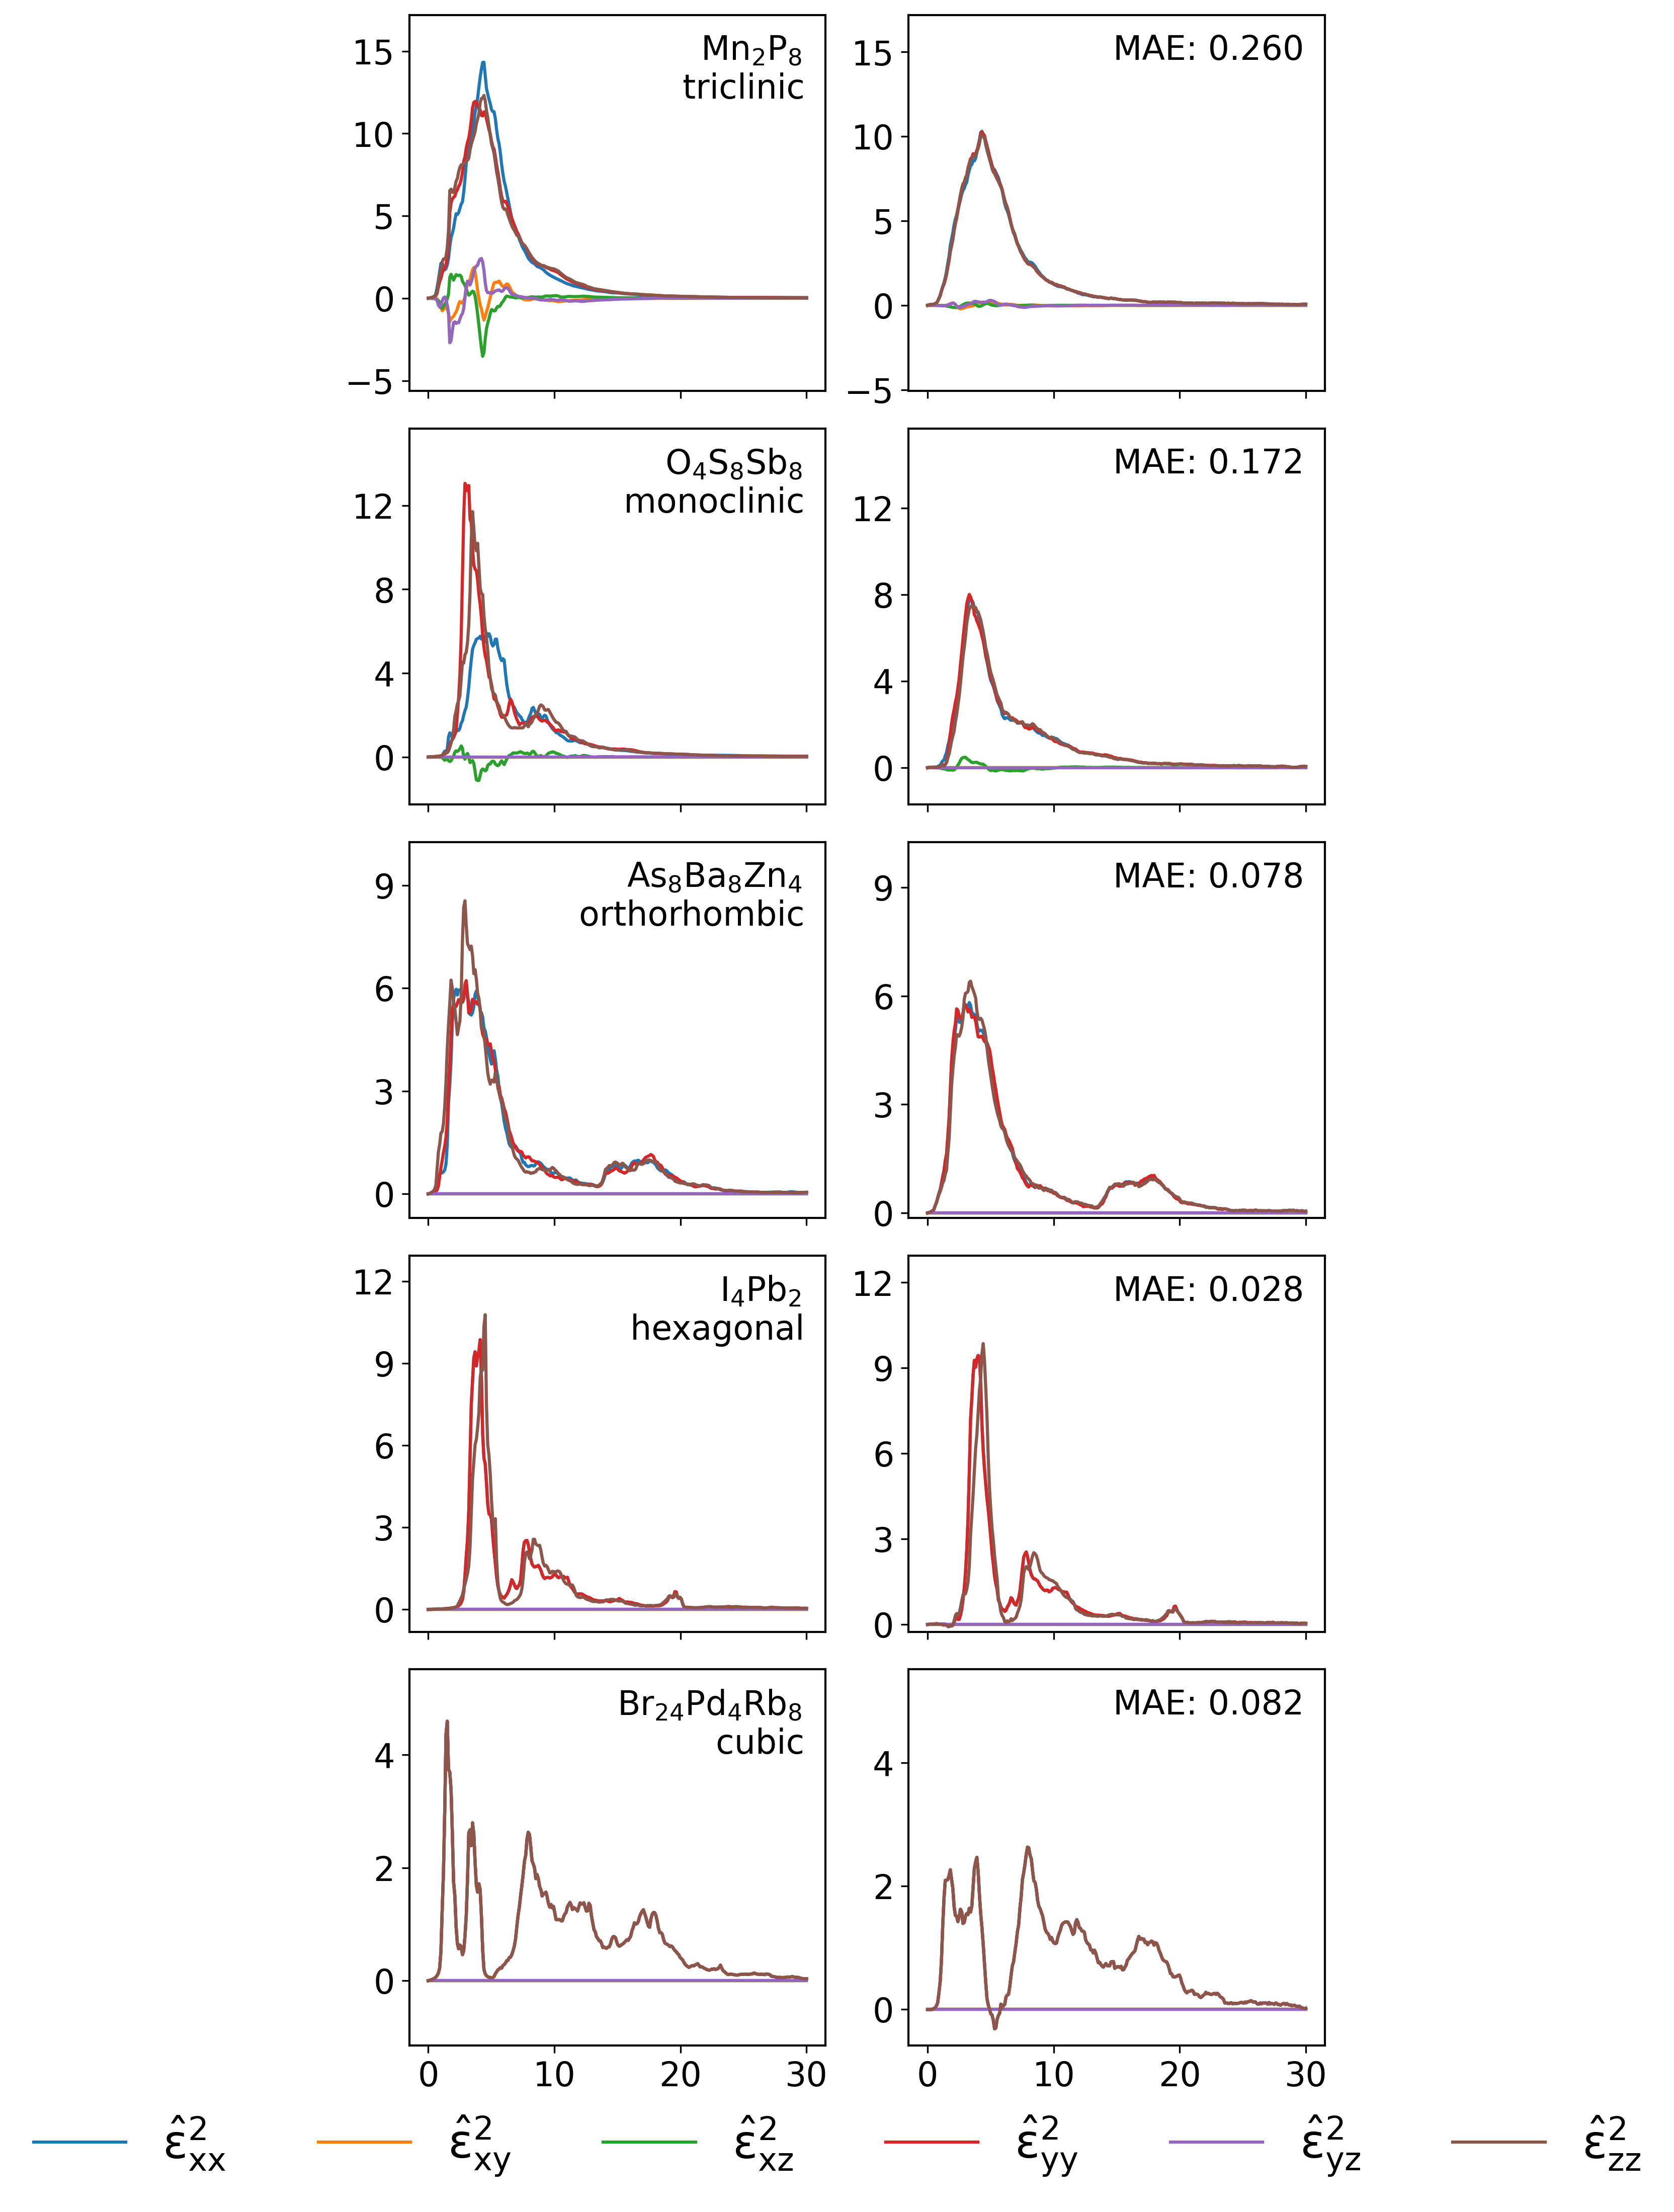

In [5]:
def get_one_sample_per_crystal_system(df, idx_test, target_systems):
    """
    Returns one index per crystal system from the test set, ordered from low to high symmetry.

    Parameters:
    - df: Full dataframe with 'crystal_system' column.
    - idx_test: List of indices belonging to the test set.
    - target_systems: List of crystal systems to include.

    Returns:
    - List of indices corresponding to one sample per crystal system, ordered by symmetry.
    """
    import random
    idx_test = list(idx_test)  # <-- COPY here, don't modify input!
    # random.seed(11)
    random.seed(20)
    random.shuffle(idx_test)

    # Define symmetry order from low to high
    symmetry_order = [
        "triclinic",
        "monoclinic",
        "orthorhombic",
        "tetragonal",
        "trigonal",
        "hexagonal",
        "cubic",
    ]

    # Filter the list to only those in target_systems, in the desired order
    ordered_targets = [s for s in symmetry_order if s in target_systems]

    # Create a lookup: crystal_system -> index
    system_to_index = {}
    seen_systems = set()

    for idx in idx_test:
        system = df.loc[idx, "crystal_system"]
        if system in ordered_targets and system not in seen_systems:
            system_to_index[system] = idx
            seen_systems.add(system)
        if len(seen_systems) == len(ordered_targets):
            break

    # Return indices in the desired symmetry order
    return [system_to_index[system] for system in ordered_targets if system in system_to_index]

    
    return selected_indices
def plot_cartesian_tensor_comparison(df, idx, column_name, title_prefix="", n=3, show_legend=True):
    """
    Plots multiple side-by-side line plots comparing predicted vs. real Cartesian tensors 
    in a more compact horizontal layout with minimal white space.

    Parameters:
    - df: Pandas DataFrame containing 'y_pred_cart' (predictions), 
          'real_Permittivity_Matrices_interp' (targets), and 'energies_interp'.
    - idx: List or array of indices to consider (e.g., idx_train, idx_test).
    - title_prefix: Prefix to be added to the plot title.
    - n: Number of samples to plot.
    """
    # Filter DataFrame based on provided indices
    ds = df.iloc[idx].reset_index(drop=True)

    # Define component labels
    xyz_list = ['x', 'y', 'z']
    tensor_components = [f"$\hat{{\epsilon}}^2_{{{xyz_list[a]}{xyz_list[b]}}}$" for a in range(3) for b in range(a, 3)]

    # Define subplot grid layout
    n_rows = n
    n_cols = 2  
    # Adjust figure size to reduce white space
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows), dpi=300, sharex=True)
    axes = axes.ravel()  # Flatten axes array for easy iteration

    handles, labels = [], []

    for i, sample_idx in enumerate(idx[:n]):  # Directly loop over provided idx
        material_id = ds.iloc[i]['mp_id']
        mae_cart = ds.iloc[i]['mae_cart']
        
        crystal_system = ds.iloc[i]['crystal_system']
        formula = ds.iloc[i]['formula']
        omega = ds["energies_interp"].iloc[i]
        formatted_formula = format_chemical_formula(formula)
        real_permittivity = ds[column_name].iloc[i]  # (num_energies, 3, 3)
        pred_permittivity = ds["y_pred_cart"].iloc[i]  # (num_energies, 3, 3)
        
        y_min = min(real_permittivity.min(), pred_permittivity.min())
        y_max = max(real_permittivity.max(), pred_permittivity.max())
        
        # Left subplot: Real permittivity
        ax_real = axes[2 * i]  # Every even index is real data
        for idx, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
            h, = ax_real.plot(omega, real_permittivity[:, a, b], label=tensor_components[idx], linestyle='-')
            if i == 0:  # Collect legend items only from the first plot
                handles.append(h)
                labels.append(tensor_components[idx])
        if column_name =="real_Permittivity_Matrices_interp":
            ax_real.set_ylim((y_min-0.1) * 1.4, y_max * 1.2)
        else:
            ax_real.set_ylim((y_min-0.5) * 1.4, y_max * 1.2)
        ax_real.text(0.95, 0.95, f"${formatted_formula}$ \n {crystal_system}", 
             transform=ax_real.transAxes, fontsize=16, verticalalignment='top', 
             horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
        ax_real.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

        # Right subplot: Predicted permittivity
        ax_pred = axes[2 * i + 1]  # Every odd index is predicted data
        for idx, (a, b) in enumerate([(x, y) for x in range(3) for y in range(x, 3)]):
            ax_pred.plot(omega, pred_permittivity[:, a, b], linestyle='-')
        if column_name =="real_Permittivity_Matrices_interp":
            ax_pred.set_ylim((y_min-0.1) * 1.4, y_max * 1.2)
        else:
            ax_pred.set_ylim((y_min-0.1) * 1.4, y_max * 1.2)

        text_str = (
            f"{'MAE:':<1} {mae_cart:>4.3f}\n"
        )

        # Add the text to the subplot
        ax_pred.text(
            0.95, 0.95,  # Position in axes coordinates (top-right)
            text_str,
            transform=ax_pred.transAxes,
            fontsize=16,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
        )
        ax_pred.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        
    # Remove x-labels from individual subplots
    for ax in axes:
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=16)  # <-- Set the x-tick label size here
    for ax in axes[-n_cols:]:  
        ax.set_xticks(np.linspace(min(omega), max(omega), 4))
        ax.tick_params(axis='x', labelsize=16)  # <-- Set the x-tick label size here
    
    if show_legend:
        fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.01), ncol=6, fontsize=22, frameon=False)
    
    plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout
    plt.subplots_adjust(wspace=0.2, hspace=0.1)  

    os.makedirs("../pngs", exist_ok=True)
    save_path = f"../pngs/{title_prefix}_cart_spectra.png"
    fig.savefig(save_path, dpi=300)

    plt.show()

target_systems = ['triclinic', 'monoclinic', 'orthorhombic', 'hexagonal', 'cubic']
representative_idx = get_one_sample_per_crystal_system(df, idx_test, target_systems)

# Then pass it to your plotting function
plot_cartesian_tensor_comparison(df, representative_idx, column_name=column, title_prefix="five_crystal_systems", n=5)



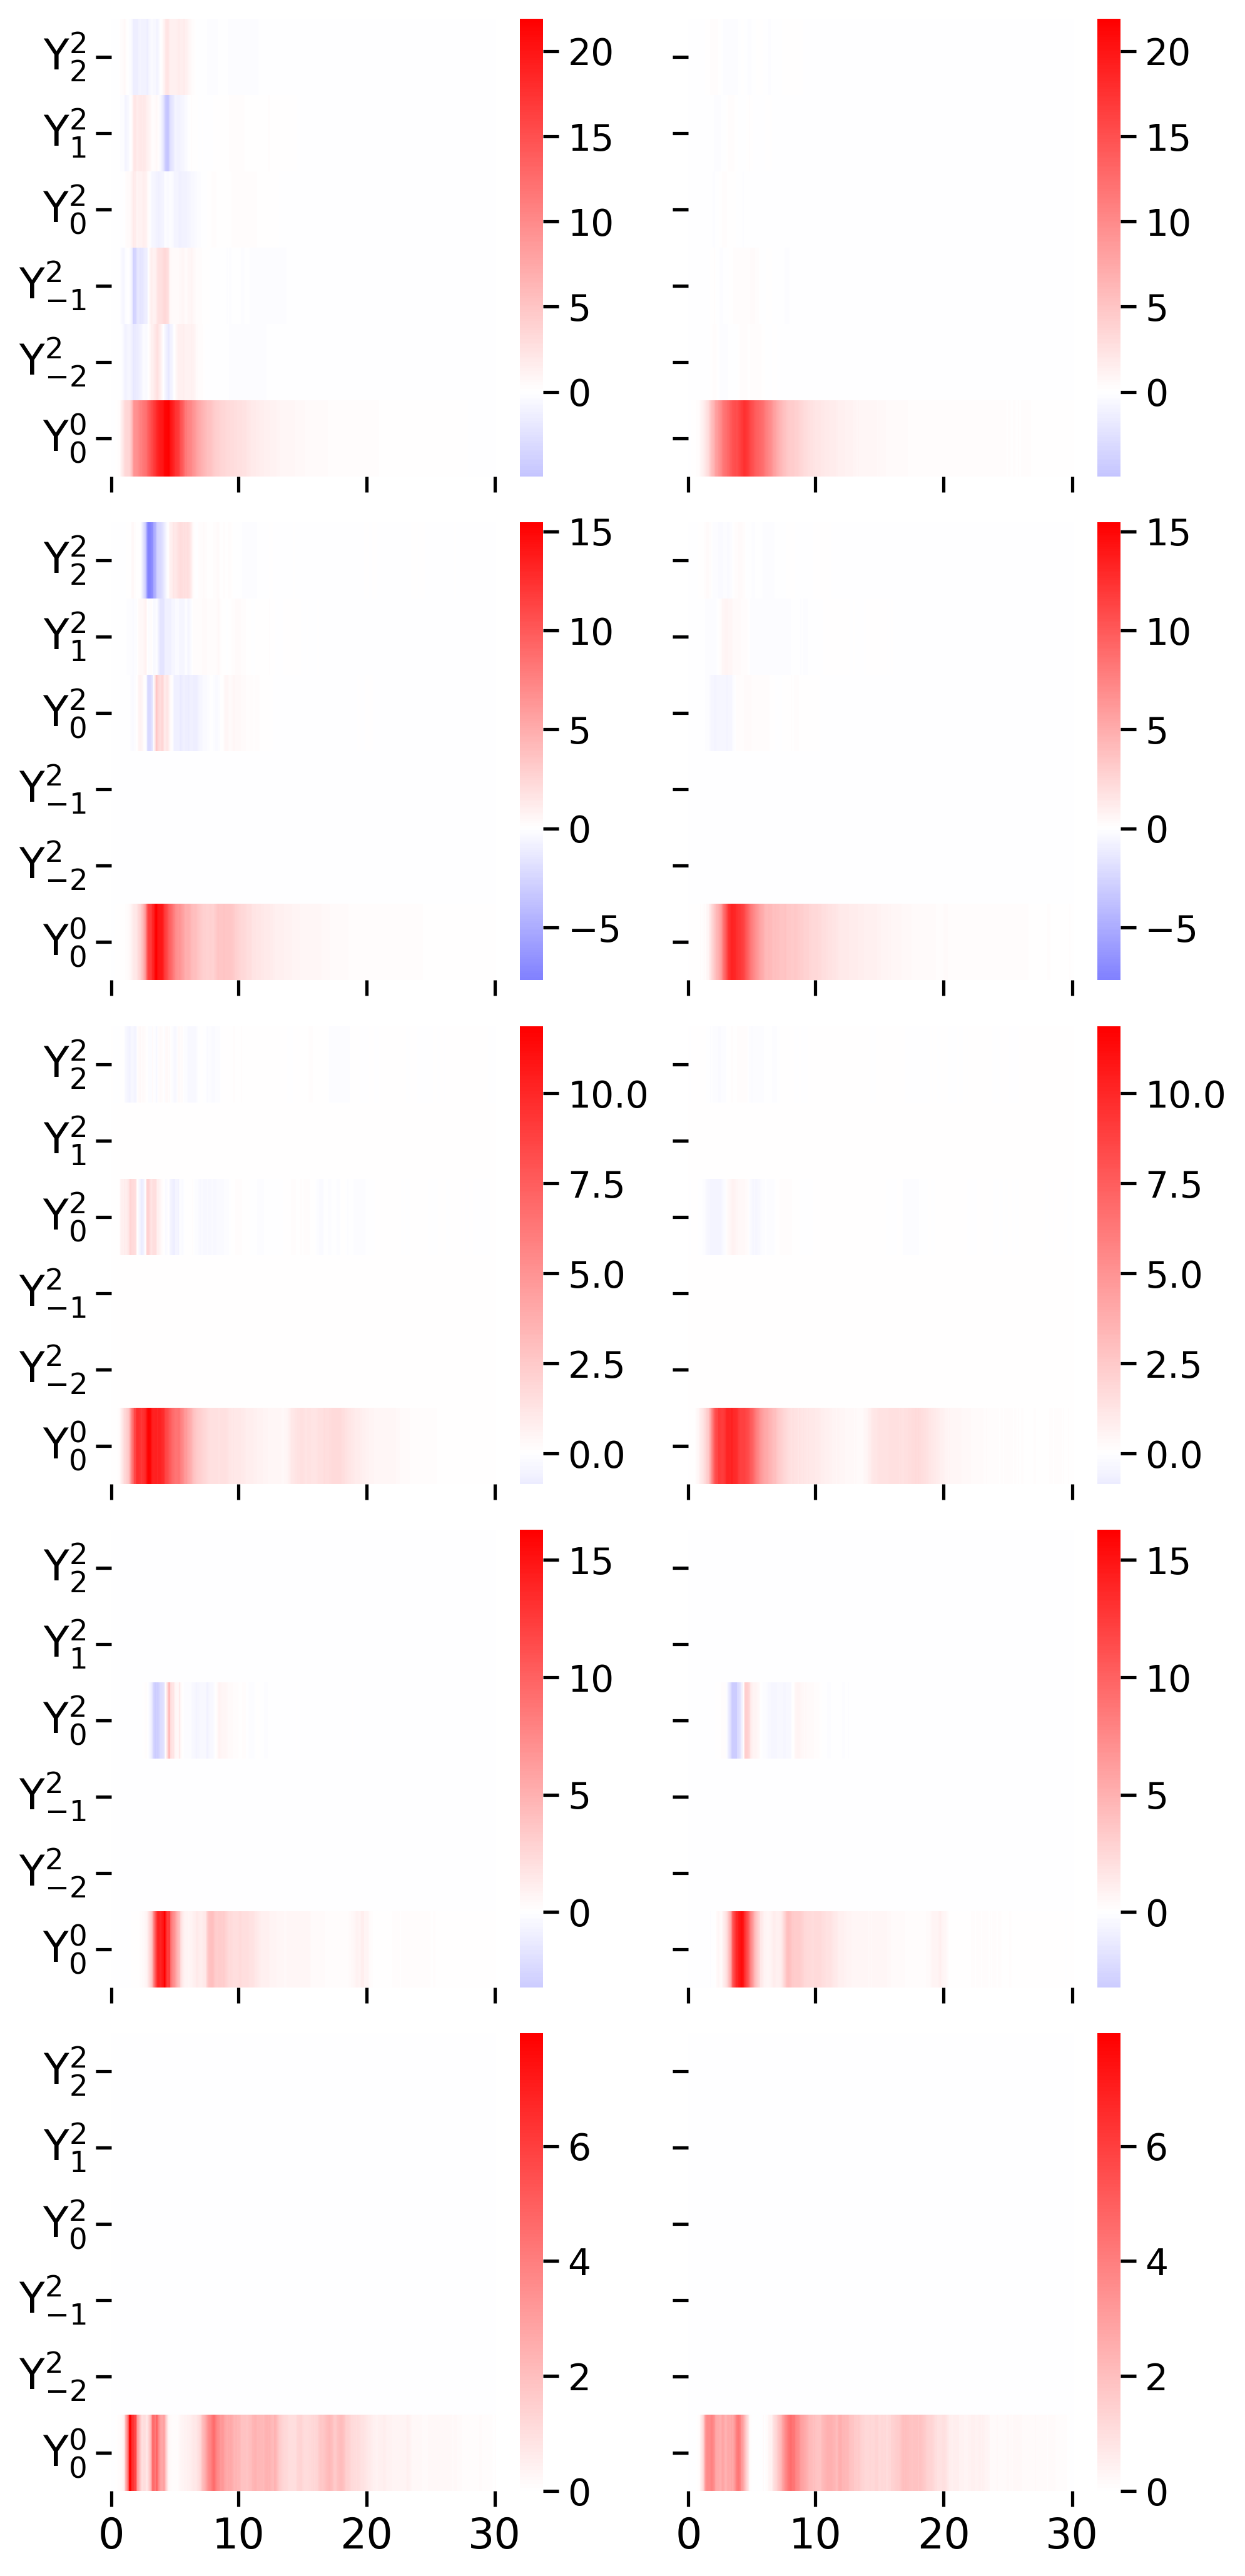

In [6]:
def plot_spherical_harmonics_comparison(df, idx, column_name, title_prefix="", n=4):
    """
    Plots heatmaps comparing target spherical harmonics with predicted spherical harmonics for multiple samples
    in a more compact layout (e.g., 4 rows × multiple columns instead of a single wide row).

    Parameters:
    - df: Pandas DataFrame containing 'sph_coefs' (targets), 'y_pred_sph' (predictions), 'mse'.
    - idx: List or array of indices to consider (e.g., idx_train, idx_test).
    - title_prefix: Prefix to be added to the plot title (e.g., Material ID).
    - n: Number of samples to plot.
    """
    # Filter DataFrame based on provided indices
    from e3nn.io import CartesianTensor
    
    with sns.plotting_context("notebook", font_scale=2):
        ct = CartesianTensor("ij=ji")
        ds = df.iloc[idx].reset_index(drop=True)

        # Extract energy grid (assume shared for all)
        omega = df["energies_interp"].iloc[0]

        # Define subplot grid layout
        # n_rows = 4  # Fixed number of rows
        # n_cols = math.ceil(n / n_rows) * 2  # Ensures space for real & predicted pairs
        n_rows = 5
        n_cols = 2
        # Setup figure with multiple rows & columns for compact layout
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3 * n_rows), sharex=True, sharey=True, dpi=300)
        axes = axes.ravel()  # Flatten axes array for easy iteration

        # Spherical harmonic component labels
        component_ticks = [r"$Y^2_2$", r"$Y^2_{1}$", r"$Y^2_0$", r"$Y^2_{-1}$", r"$Y^2_{-2}$", r"$Y^0_0$"]
        # component_ticks = [
        #     r"",
        #     r"",
        #     r"",
        #     r"",
        #     r"",
        #     r""
        # ]

        for i, sample_idx in enumerate(idx[:n]):  # Use provided indices directly
            material_id = ds.iloc[i]['mp_id']
            crystal_system = ds.iloc[i]['crystal_system']
            real_permittivity = ds[column_name].iloc[i]  # (num_energies, 3, 3)
            pred_permittivity = ds["y_pred_cart"].iloc[i]  # (num_energies, 3, 3)
            perm = torch.tensor([1, 2, 0])  # Permutation: x->2, y->0, z->1

            # Convert to torch tensors if not already
            real_permittivity = torch.tensor(real_permittivity) if not torch.is_tensor(real_permittivity) else real_permittivity
            pred_permittivity = torch.tensor(pred_permittivity) if not torch.is_tensor(pred_permittivity) else pred_permittivity

            # Permute the 3x3 dimensions (axes 1 and 2)
            real_permittivity_permuted = real_permittivity[:, perm, :][:, :, perm]  # Shape: [201, 3, 3]
            pred_permittivity_permuted = pred_permittivity[:, perm, :][:, :, perm]  # Shape: [201, 3, 3]

            real_sph = ct.from_cartesian(real_permittivity_permuted)
            pred_sph = ct.from_cartesian(pred_permittivity_permuted)

            # Extract target and prediction, then transpose & reverse for correct visualization
            X_irrep_target = real_sph.numpy().T[::-1, :]
            X_irrep_pred = pred_sph.numpy().T[::-1, :]
            vmin = X_irrep_target.min()
            vmax = X_irrep_target.max()
            # Left: Target heatmap
            ax_target = axes[2 * i]
            sns.heatmap(X_irrep_target, cmap='bwr', center=0, ax=ax_target,
                        yticklabels=component_ticks, xticklabels=50,
                        vmin=vmin, vmax=vmax)

            ax_target.tick_params(axis='x', rotation=0, labelsize=16)  
            ax_target.tick_params(axis='y', rotation=0, labelsize=16)  

            # Right: Predicted heatmap
            ax_pred = axes[2 * i + 1]
            sns.heatmap(X_irrep_pred, cmap='bwr', center=0, ax=ax_pred,
                        yticklabels=component_ticks, xticklabels=50,
                        vmin=vmin, vmax=vmax)

            ax_pred.tick_params(axis='x', rotation=0, labelsize=16)  
            ax_pred.tick_params(axis='y', rotation=0, labelsize=16)  

        # Set x-axis ticks at reasonable intervals
        num_omega = len(omega)
        tick_indices = np.linspace(0, num_omega - 1, 4, dtype=int)  
        tick_labels = [int(round(omega[idx])) for idx in tick_indices]  

        for ax in axes[:2 * n]:
            if ax.collections:  
                cbar = ax.collections[0].colorbar
                cbar.ax.tick_params(labelsize=14)  # <-- make colorbar tick labels smaller
        for ax in axes[:2 * n]:  
            ax.set_xticks(tick_indices)
            ax.set_xticklabels(tick_labels)

        plt.tight_layout(rect=[0, 0.05, 1, 1])  
        plt.subplots_adjust(wspace=0.2, hspace=0.1)  
        os.makedirs("../pngs", exist_ok=True)
        save_path = f"../pngs/{title_prefix}_spectra.png"
        fig.savefig(save_path, dpi=300)

        plt.show()

plot_spherical_harmonics_comparison(df, representative_idx, column, title_prefix="testing_set", n=5)


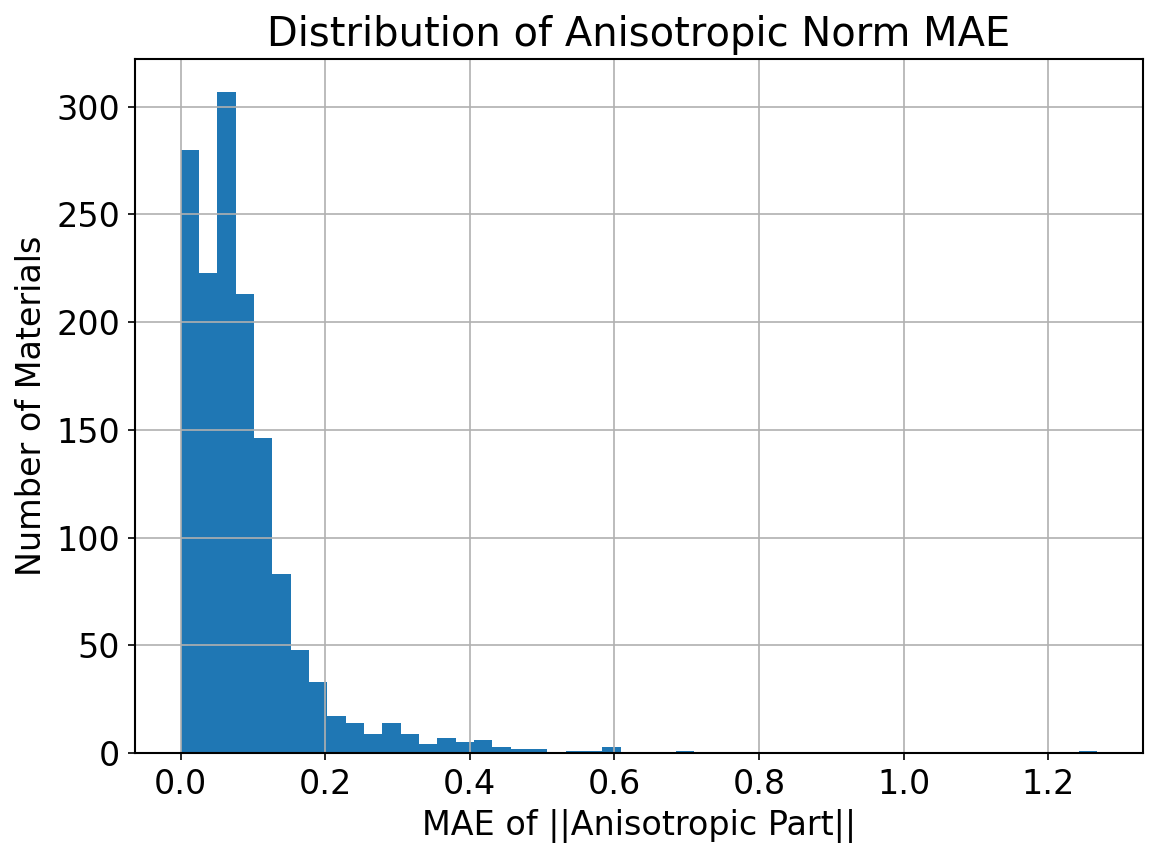

Mean MAE: 0.0856
Standard Deviation: 0.0901


In [7]:
def decompose_tensor_seq(tensor_seq):
    iso_parts = []
    aniso_parts = []
    for tensor in tensor_seq:
        iso, aniso = decompose_tensor((tensor + tensor.T.conj()) / 2)
        iso_parts.append(iso)
        aniso_parts.append(aniso)
    return np.array(iso_parts), np.array(aniso_parts)

def decompose_tensor(tensor):
    """
    Input: tensor of shape (3, 3)
    Returns: (iso_part, aniso_part), both (3, 3)
    """
    iso_scalar = np.trace(tensor) / 3
    iso_part = iso_scalar * np.eye(3)
    aniso_part = tensor - iso_part
    return iso_part, aniso_part

def anisotropy_strength(aniso_seq):
    return np.linalg.norm(aniso_seq, axis=(1,2))  # [n_freq]

def compute_aniso_mae(row):
    true_tensor = row["rel_permittivity_imag_interp"]
    pred_tensor = row["y_pred_cart"]

    true_iso, true_aniso = decompose_tensor_seq(true_tensor)
    pred_iso, pred_aniso = decompose_tensor_seq(pred_tensor)

    true_norm = anisotropy_strength(true_aniso)
    pred_norm = anisotropy_strength(pred_aniso)

    # Mask out invalid values
    mask = np.isfinite(true_norm) & np.isfinite(pred_norm)
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs(true_norm[mask] - pred_norm[mask]))

df['aniso_norm_mae'] = df.apply(compute_aniso_mae, axis=1)
plt.figure(figsize=(8, 6))
df['aniso_norm_mae'].dropna().hist(bins=50)
plt.xlabel("MAE of ||Anisotropic Part||")
plt.ylabel("Number of Materials")
plt.title("Distribution of Anisotropic Norm MAE")
plt.tight_layout()
plt.show()
mean_mae = df['aniso_norm_mae'].mean()
std_mae = df['aniso_norm_mae'].std()

print(f"Mean MAE: {mean_mae:.4f}")
print(f"Standard Deviation: {std_mae:.4f}")

Test


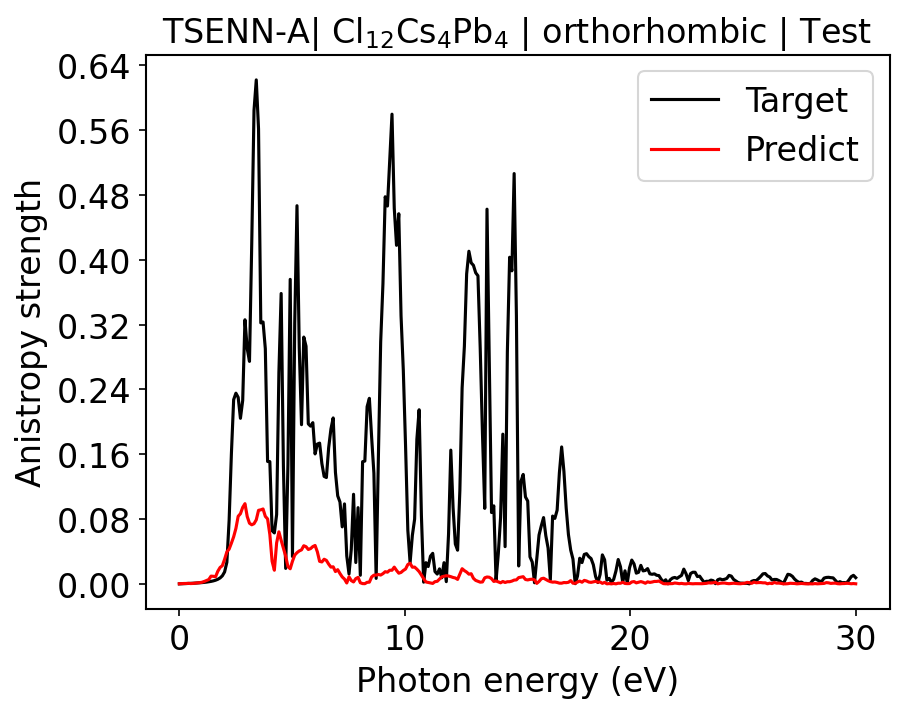

0.08550579896821195


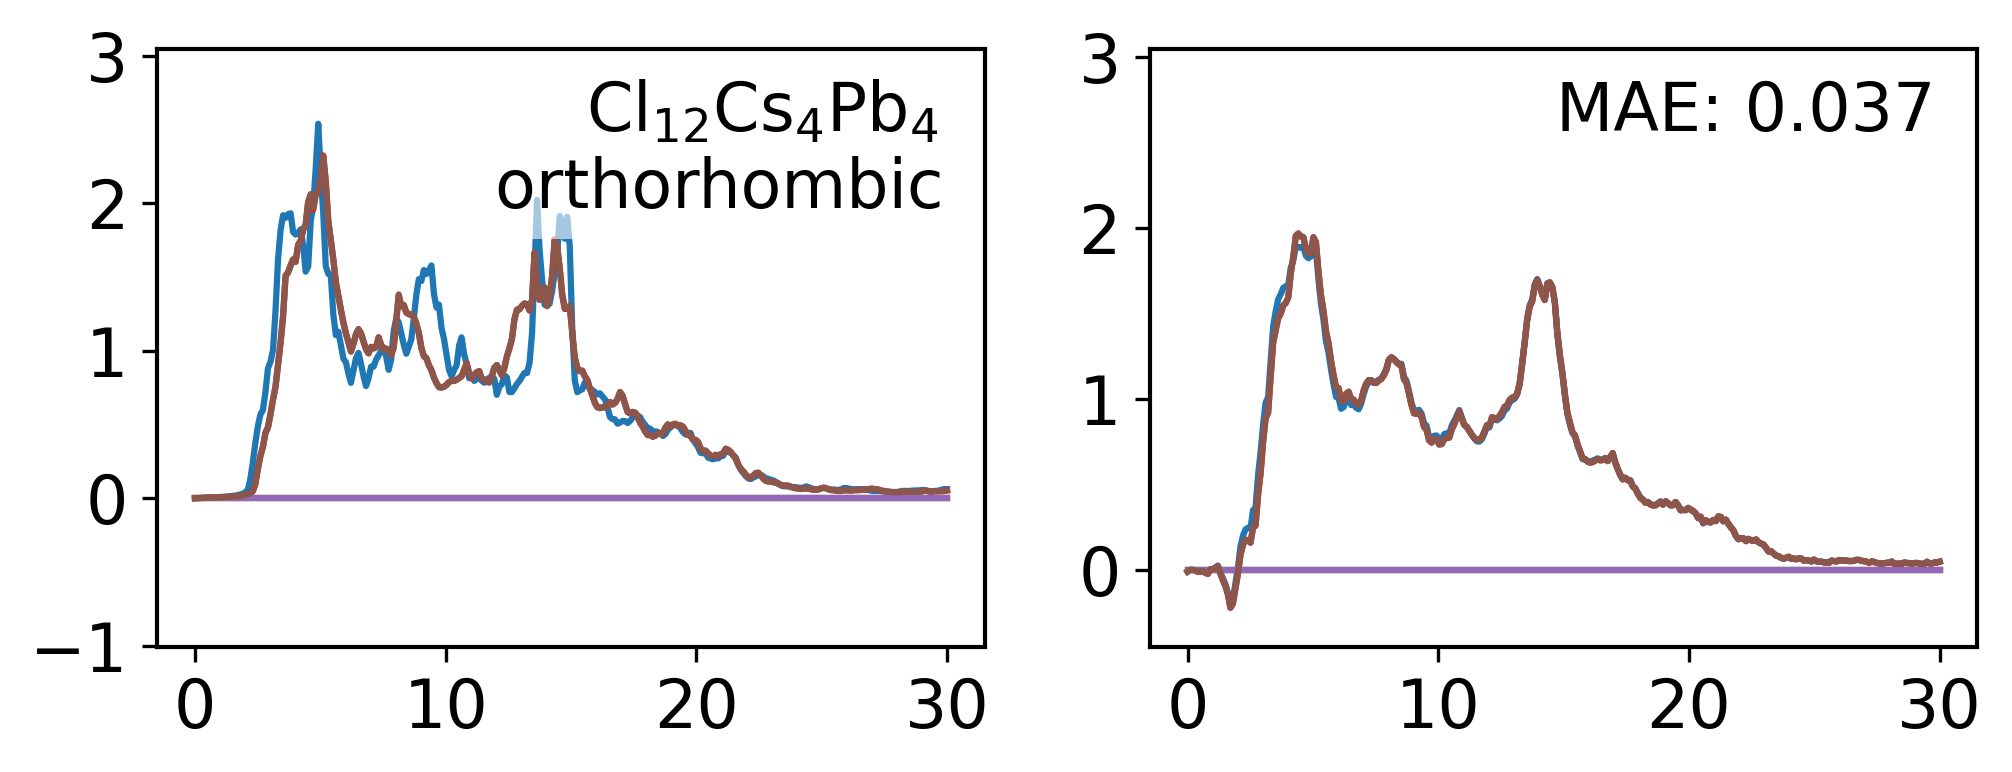

In [16]:
# row = df.iloc[1423] # cubic
# row = df.iloc[2] # monoclinic
# row = df.iloc[1411] # tetragonal
# row = df[df.formula=="Ag4S2"].iloc[0]
row = df[df.formula =="Cl12Cs4Pb4"].iloc[1]
# row = df[df.formula=="K4O8Sb4"].iloc[0]
print(row.split)
# row = df.iloc[476] # tetragonal
true_tensor = row["rel_permittivity_imag_interp"]
pred_tensor = row["y_pred_cart"]

true_iso, true_aniso = decompose_tensor_seq(true_tensor)
pred_iso, pred_aniso = decompose_tensor_seq(pred_tensor)

true_norm = anisotropy_strength(true_aniso)
pred_norm = anisotropy_strength(pred_aniso)

# plt.title(f"{row.mp_id} | {row.crystal_system} | {row.split}")
# print(f"{row.mp_id} | {row.crystal_system} | {row.split}")
info_label = f"{row.mp_id} | {row.crystal_system} "
model_label = f"TSENN-A"

fig, ax = plt.subplots()



plt.title(f"{model_label}| ${format_chemical_formula(row.formula)}$ | {row.crystal_system} | {row.split}", fontsize=16)
plt.plot(row.energies_interp, true_norm, label="Target", color='k')
plt.plot(row.energies_interp, pred_norm, label="Predict", color ='r')
# plt.plot([], [], ' ', label=f"${{MAE}}^{{aniso}}_{{norm}}$: {np.mean(true_norm-pred_norm):.4f}")
# plt.plot([], [], ' ', label=f"${{MAE}}^{{aniso}}_{{norm}}$: {np.mean(true_norm-pred_norm):.4f}")

ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
x_ticks = np.linspace(row.energies_interp[0], row.energies_interp[-1], 4)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{v:.0f}" for v in x_ticks])  # integer labels

ax.set_xlabel(r"Photon energy (eV)")
ax.set_ylabel("Anistropy strength")
ax.legend()
plt.show()


print(np.mean(true_norm-pred_norm))

plot_cartesian_tensor_comparison(df, [row.name], column_name=column, title_prefix="five_crystal_systems", n=1, show_legend=False)




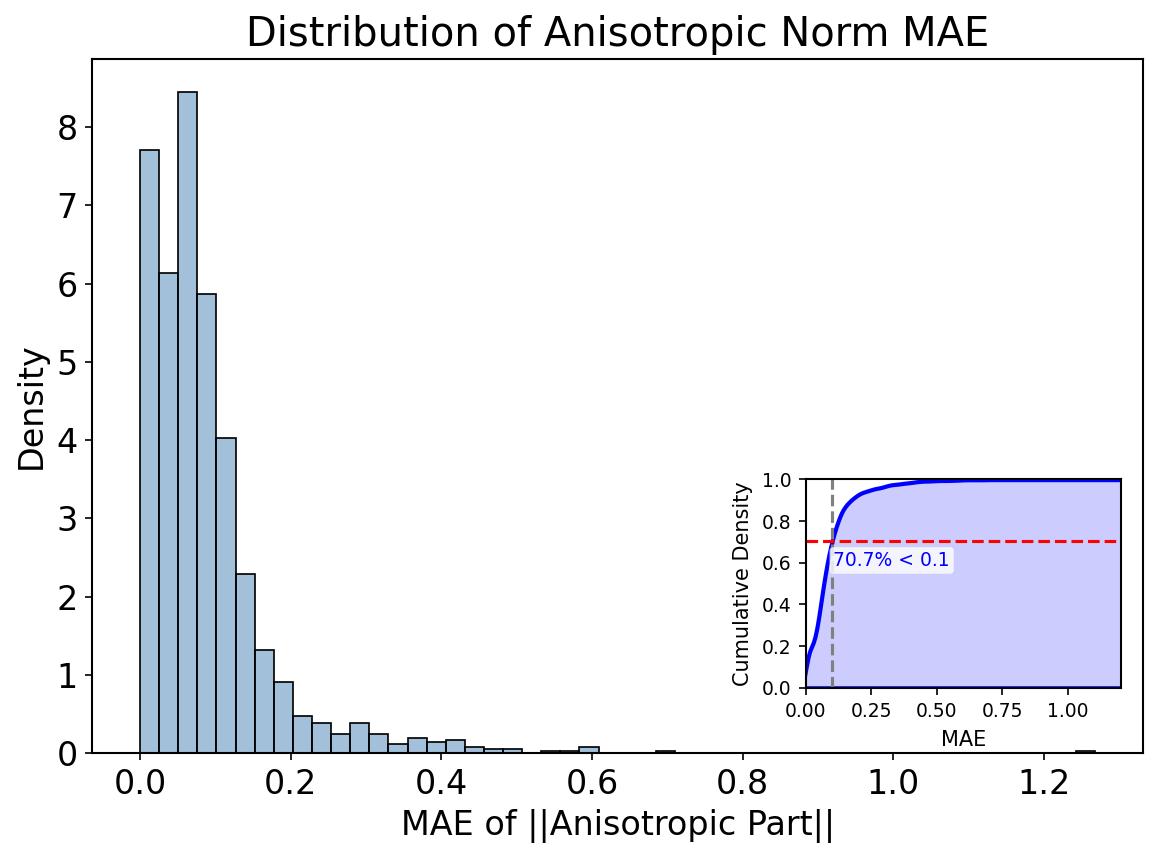

In [9]:
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import numpy as np

# Ensure clean data
aniso_mae = df['aniso_norm_mae'].dropna().values
threshold = 0.1

epsilon = 1e-8  # Prevent divide-by-zero
rel_error = np.abs((true_norm - pred_norm) / (np.abs(true_norm) + epsilon))

# Create main plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(aniso_mae, bins=50, stat='density', ax=ax, color='steelblue', alpha=0.5)
ax.set_xlabel("MAE of ||Anisotropic Part||")
ax.set_ylabel("Density")
ax.set_title("Distribution of Anisotropic Norm MAE")

# Create inset axes
inset_ax = inset_axes(ax, width="30%", height="30%", loc='lower right', 
                      bbox_to_anchor=(-0.005, 0.07, 1, 1), bbox_transform=ax.transAxes)

# KDE CDF
sns.kdeplot(aniso_mae, ax=inset_ax, color='blue', fill=True, cumulative=True,
            bw_adjust=0.5, alpha=0.2, linewidth=2)

# Axes settings
inset_ax.set_xlabel("MAE", fontsize=10)
inset_ax.set_ylabel("Cumulative Density", fontsize=10)
inset_ax.tick_params(axis='both', labelsize=9)
inset_ax.set_xlim(0, np.max(aniso_mae) * 0.95)
inset_ax.set_ylim(0, 1)

# Compute % below threshold
perc_below = np.mean(aniso_mae < threshold) * 100
inset_ax.axvline(x=threshold, color='gray', linestyle='--', linewidth=1.5)
inset_ax.axhline(y=perc_below / 100, color='red', linestyle='--', linewidth=1.5)

inset_ax.text(threshold + 0.005, perc_below / 100 - 0.05,
              f'{perc_below:.1f}% < {threshold}',
              color='blue', fontsize=9, ha='left', va='top',
              bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
